In [43]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
import anndata as ad 
from importlib import reload
from scipy.sparse import coo_matrix

import h5py
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 
reload(llc)

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking_BBFactor as mask 
reload(mask) 

import cost_correlation_assign
from cost_correlation_assign import *

reload(cost_correlation_assign)
from differential_splicing import * 

### Device settings 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')
    
float_type = { 
        "device": device, 
        "dtype": torch.float,
    }

input_conc = torch.tensor(np.inf, **float_type)
print(input_conc)

2.3.0+cu121
12.1
Using device: cuda
Using device: cuda
tensor(inf)


### Load real brain single cell data from Tabula Senis

In [2]:
adata = ad.read_h5ad('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters_adata.h5ad')
adata.obs["cell_id_index"] = adata.obs.index
print(f"Original Cluster_Counts nnz: {adata.layers['Cluster_Counts'].count_nonzero()}")
print(f"Original Junction_Counts nnz: {adata.layers['Junction_Counts'].count_nonzero()}")

#cell_type_column = "cell_ontology_class"
#filter_clusters = True

cell_type_column = None
filter_clusters = False # in this case maybe better to first assign random clustesr outside of simulaiton code 
K_use = 3

# Load Anndata object
adata_input = adata.copy()  # Make a copy to avoid modifying the original data
proportion_negative = 0.5

# If cell type column is present in adata.obs, then set K to the number of unique cell types
if cell_type_column in adata.obs.columns:
    K = adata.obs[cell_type_column].nunique()
    
    # Print the unique cell types and their counts
    unique_cell_types = adata.obs[cell_type_column].value_counts()
    print(f"Unique cell types in '{cell_type_column}':")
    print(unique_cell_types)

else:
    K = K_use

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Original Cluster_Counts nnz: 29565846
Original Junction_Counts nnz: 13523365


### Remove lowly observed ATSEs!!

In [3]:
if filter_clusters:
    
    # Extract the cluster counts matrix (C x J) and cell types
    cluster_counts = adata_input.layers["Cluster_Counts"]
    cell_types = adata_input.obs[cell_type_column].values

    print(adata_input.layers["Cluster_Counts"].shape, adata_input.layers["Junction_Counts"].shape)

    # Get unique cell types and clusters
    unique_cell_types = np.unique(cell_types)
    unique_clusters = adata_input.var_names # assuming var_names corresponds to junction clusters

    # Initialize a DataFrame to store the counts
    expression_counts = pd.DataFrame(0, index=unique_cell_types, columns=unique_clusters)

    # Calculate the number of cells expressing each intron cluster for each cell type
    for cell_type in tqdm(unique_cell_types):
        cells_in_type = (cell_types == cell_type)
        counts_in_type = cluster_counts.toarray()[cells_in_type, :].sum(axis=0) # number of cells in cell type found for each cluster pair 
        expression_counts.loc[cell_type] = counts_in_type  # .A converts sparse matrix to dense array

    # Calculate the number of cell types where each cluster has non-zero (and > 5) expression
    non_zero_counts = (expression_counts >= 5).sum(axis=0)

    # Calculate the threshold for filtering (20% of total cell types)
    threshold = len(expression_counts) * 0.2
    print(threshold) 

    # Filter clusters that are expressed in more than 25% of cell types
    filtered_clusters = non_zero_counts[non_zero_counts > threshold].index

    # Subset the original DataFrame to keep only the filtered clusters
    filtered_expression_counts = expression_counts[filtered_clusters]

    # Juncs to keep 
    juncs_keep = list(filtered_expression_counts)

    # Subset Anndata vars to only these adata_input.var_names along with adata layers 
    adata_filtered = adata_input[:, juncs_keep].copy()

    # need to ensure indices of junctions/clustesr are still concordant across var info and counts matrices 
    adata_filtered.var['junction_id_index'] = np.arange(adata_filtered.n_vars)
    adata_filtered.var_names = adata_filtered.var['junction_id_index'].astype(str)
    print(adata_filtered.layers["Cluster_Counts"].shape, adata_filtered.layers["Junction_Counts"].shape)

else:
    adata_filtered = adata_input.copy()

### Simulate data!

In [4]:
adata_input = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, cell_type_column)

# Index clean up 
adata_input.obs.drop(columns=['cell_id_index'], inplace=True)
adata_input.obs.reset_index(inplace=True)

Cluster_Counts nnz: 10020363
Junction_Counts nnz: 5217550
The number of unique junctions included in the simulation data is: 17703
The number of unique clusters included in the simulation data is: 5901


100%|██████████| 5901/5901 [00:11<00:00, 529.57it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 10020363
Junction_Counts nnz: 5217550
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 3
The number of cells is: 12657
The number of junctions is: 17703
Number of negative labels (0): 2950
Number of positive labels (1): 2951


100%|██████████| 5901/5901 [00:21<00:00, 278.79it/s]


Assertion passed: 'junction_id_index' matches the index in 'adata_input.var'.
Done simulating PSI!
Done simulating junction counts!
True label counts:
 true_label
negative    9429
positive    8274
Name: count, dtype: int64
Sample label counts:
 sample_label
positive    8853
negative    8850
Name: count, dtype: int64
Cluster_Counts nnz: 10020363
Junction_Counts nnz: 9007945
Data successfully simulated and prepared!


### Mask some data for imputation analysis

In [44]:
# Define possible masking percentages, input_conc values, and use_global_prior flags

masks = [0.999999, 0.5, 0.05]

# input_conc_options = [torch.tensor(np.inf, **float_type), None]
# use_global_prior_options = [True, False]

input_conc_options = [torch.tensor(np.inf, **float_type)]
use_global_prior_options = [False]

num_epochs=40
num_inits=3
lr=0.1

# Initialize dictionaries to store the results for the factor model and NMF baseline
factor_metrics = {'mask': [], 'l1_error': [], 'spearman_cor': [], 'l2_error': [], 'rmse': [], 'log_likelihood': []}
nmf_metrics = {'mask': [], 'l1_error': [], 'spearman_cor': [], 'l2_error': [], 'rmse': []}

In [45]:
reload(factor_model)
reload(mask)

2.3.0+cu121
12.1
Using device: cuda


<module 'masking_BBFactor' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking_BBFactor.py'>

In [46]:
# Loop through different model parameter combinations and masking percentages
for mask_percentage in masks:
            
    print(f"Masking {mask_percentage} of the non-zero intron cluster counts!")

    # 1. Generate the mask
    mask_gen, seed = mask.generate_mask(adata_input, layer_key="Cluster_Counts", mask_percentage=mask_percentage)

    # 2. Apply the mask to create a new masked AnnData object
    masked_adata, my_data = mask.apply_mask_to_anndata(adata_input, mask_gen, cluster_layer="Cluster_Counts", junction_layer="Junction_Counts")

    # Convert sparse CSR tensor to dense format, then count non-zero elements
    non_zero_ycount = my_data.ycount_lookup.to_dense().nonzero().size(0)
    non_zero_tcount = my_data.tcount_lookup.to_dense().nonzero().size(0)

    print(f"Mask percentage: {mask_percentage}, Non-zero ycount: {non_zero_ycount}, Non-zero tcount: {non_zero_tcount}")

    # Convert the CSR tensor to COO format
    full_y_tensor = my_data.ycount_lookup.to_sparse_coo()
    full_total_counts_tensor = my_data.tcount_lookup.to_sparse_coo()

    for input_conc in input_conc_options:
        for use_global_prior in use_global_prior_options:
            print(f"Running experiment with mask={mask_percentage}, input_conc={input_conc}, use_global_prior={use_global_prior}")

            # 3. Run the factor model with the specified number of initializations and epochs
            all_results, variable_sizes = factor_model.main(
                full_y_tensor, full_total_counts_tensor, num_initializations=num_inits, 
                use_global_prior=use_global_prior, K=K, lr=lr, input_conc_prior=input_conc, 
                loss_plot=False, num_epochs=num_epochs, save_to_file=False
            )

            # Loop over all initializations and evaluate each one
            for init_idx, result in enumerate(all_results):
                print(f"Evaluating initialization {init_idx + 1}...")

                # Extract latent variables for this initialization
                latent_vars = result['summary_stats']
                assign_post = latent_vars["assign"]["mean"]
                psis = latent_vars["psi"]["mean"]

                # 4. Evaluate the factor model's performance on the masked data for this initialization
                l1_error, spearman_cor, l2_error, rmse, log_likelihood = mask.evaluate_model(
                    masked_adata, mask_gen, psis, assign_post, input_conc, 
                    true_juncs_layer="Original_Junction_Counts", true_clusts_layer="Original_Cluster_Counts"
                )

                # Store factor model results for this initialization
                factor_metrics['mask'].append(mask_percentage)
                factor_metrics['l1_error'].append(l1_error)
                factor_metrics['spearman_cor'].append(spearman_cor)
                factor_metrics['l2_error'].append(l2_error)
                factor_metrics['rmse'].append(rmse)
                factor_metrics['log_likelihood'].append(log_likelihood)

            # 5. Run MiniBatch NMF as a baseline (only once per combination of parameters)
            W, H = mask.run_minibatch_nmf_baseline(masked_adata, mask_gen, n_components=K)

            # 6. Evaluate MiniBatch NMF results using evaluate_model
            nmf_l1_error, nmf_spearman_cor, nmf_l2_error, nmf_rmse, _ = mask.evaluate_model(
                adata=masked_adata, mask=mask_gen, model_psi=H, model_assign=W, 
                true_juncs_layer="Original_Junction_Counts", true_clusts_layer="Original_Cluster_Counts"
            )

            # Store NMF results
            nmf_metrics['mask'].append(mask_percentage)
            nmf_metrics['l1_error'].append(nmf_l1_error)
            nmf_metrics['spearman_cor'].append(nmf_spearman_cor)
            nmf_metrics['l2_error'].append(nmf_l2_error)
            nmf_metrics['rmse'].append(nmf_rmse)

            print("-----------------------------------------------------------------------------")

Masking 0.999999 of the non-zero intron cluster counts!
Total masked entries: 10020352.0


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Unique cell indices: 9


Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
Not using priors on a and b, running simpler non-hierarchical version!


Mask percentage: 0.999999, Non-zero ycount: 9, Non-zero tcount: 9
Running experiment with mask=0.999999, input_conc=inf, use_global_prior=False
Random seeds: [2811, 3861, 3516]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 2811
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cuda
Training in progress for 40 epochs!
Epoch 0, Elbo loss: 241738.02260161025


...

Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------
------------------------------------------------
Model variable sizes: {'a': torch.Size([]), 'b': torch.Size([]), 'psi': torch.Size([3, 17703]), 'pi': torch.Size([3]), 'dir_conc': torch.Size([]), 'assign': torch.Size([12657, 3])}
------------------------------------------------
Evaluating initialization 1...


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking_BBFactor.py:181: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs.toarray() / true_clusts.toarray()


Number of values in masked_pred 501018
Number of values in masked_true_psi 501018
L1 error: 0.09918595229515347
Spearman correlation: 0.8042416187732164
L2 error: 0.02313794906427986
RMSE: 0.15211163355996102
Log-likelihood: -4073215.1170715997
Evaluating initialization 2...
Number of values in masked_pred 501018
Number of values in masked_true_psi 501018
L1 error: 0.12585420808599423
Spearman correlation: 0.675183278206571
L2 error: 0.031559160197937926
RMSE: 0.1776489802896091
Log-likelihood: -6459068.742427853
Evaluating initialization 3...
Number of values in masked_pred 501018
Number of values in masked_true_psi 501018
L1 error: 0.1324598925953055
Spearman correlation: 0.6494304181448142
L2 error: 0.03337661037013907
RMSE: 0.1826926664377612
Log-likelihood: -7250781.257612995
Finished fitting NMF with 3 components.


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking_BBFactor.py:181: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs.toarray() / true_clusts.toarray()


Number of values in masked_pred 501018
Number of values in masked_true_psi 501018
L1 error: 0.2662404428457452
Spearman correlation: 0.362088805722504
L2 error: 0.12290820232340617
RMSE: 0.3505826611847856
Log-likelihood: nan
-----------------------------------------------------------------------------


In [49]:
# Summarize the results into a DataFrame
factor_df = pd.DataFrame(factor_metrics)
nmf_df = pd.DataFrame(nmf_metrics)
factor_df["method"] = "LeafletFA"

# Remove 'log_likelihood' column from factor_df
if 'log_likelihood' in factor_df.columns:
    factor_df = factor_df.drop(columns=['log_likelihood'])

nmf_df["method"] = "NMF"

# Assuming factor_df and nmf_df already have their metrics and "method" column
combined_df = pd.concat([factor_df, nmf_df], ignore_index=True)
combined_df["use_global_prior"] = use_global_prior
combined_df["input_conc"] = input_conc

# Melt the DataFrame to make it long-form for easier Seaborn plotting
combined_melted_df = combined_df.melt(
        id_vars=["method", "mask", "use_global_prior", "input_conc"],  # Include additional columns in id_vars
        value_vars=["l1_error", "spearman_cor", "l2_error", "rmse"],
        var_name="Metric", value_name="Value"
    )

In [50]:
combined_melted_df

,method,mask,use_global_prior,input_conc,Metric,Value
0,LeafletFA,0.999999,False,tensor(inf),l1_error,0.212687
1,LeafletFA,0.999999,False,tensor(inf),l1_error,0.525216
2,LeafletFA,0.999999,False,tensor(inf),l1_error,0.305266
3,LeafletFA,0.500000,False,tensor(inf),l1_error,0.121231
4,LeafletFA,0.500000,False,tensor(inf),l1_error,0.087619
5,LeafletFA,0.500000,False,tensor(inf),l1_error,0.132855
6,LeafletFA,0.050000,False,tensor(inf),l1_error,0.099186
7,LeafletFA,0.050000,False,tensor(inf),l1_error,0.125854
8,LeafletFA,0.050000,False,tensor(inf),l1_error,0.132460
9,NMF,0.999999,False,tensor(inf),l1_error,0.333330


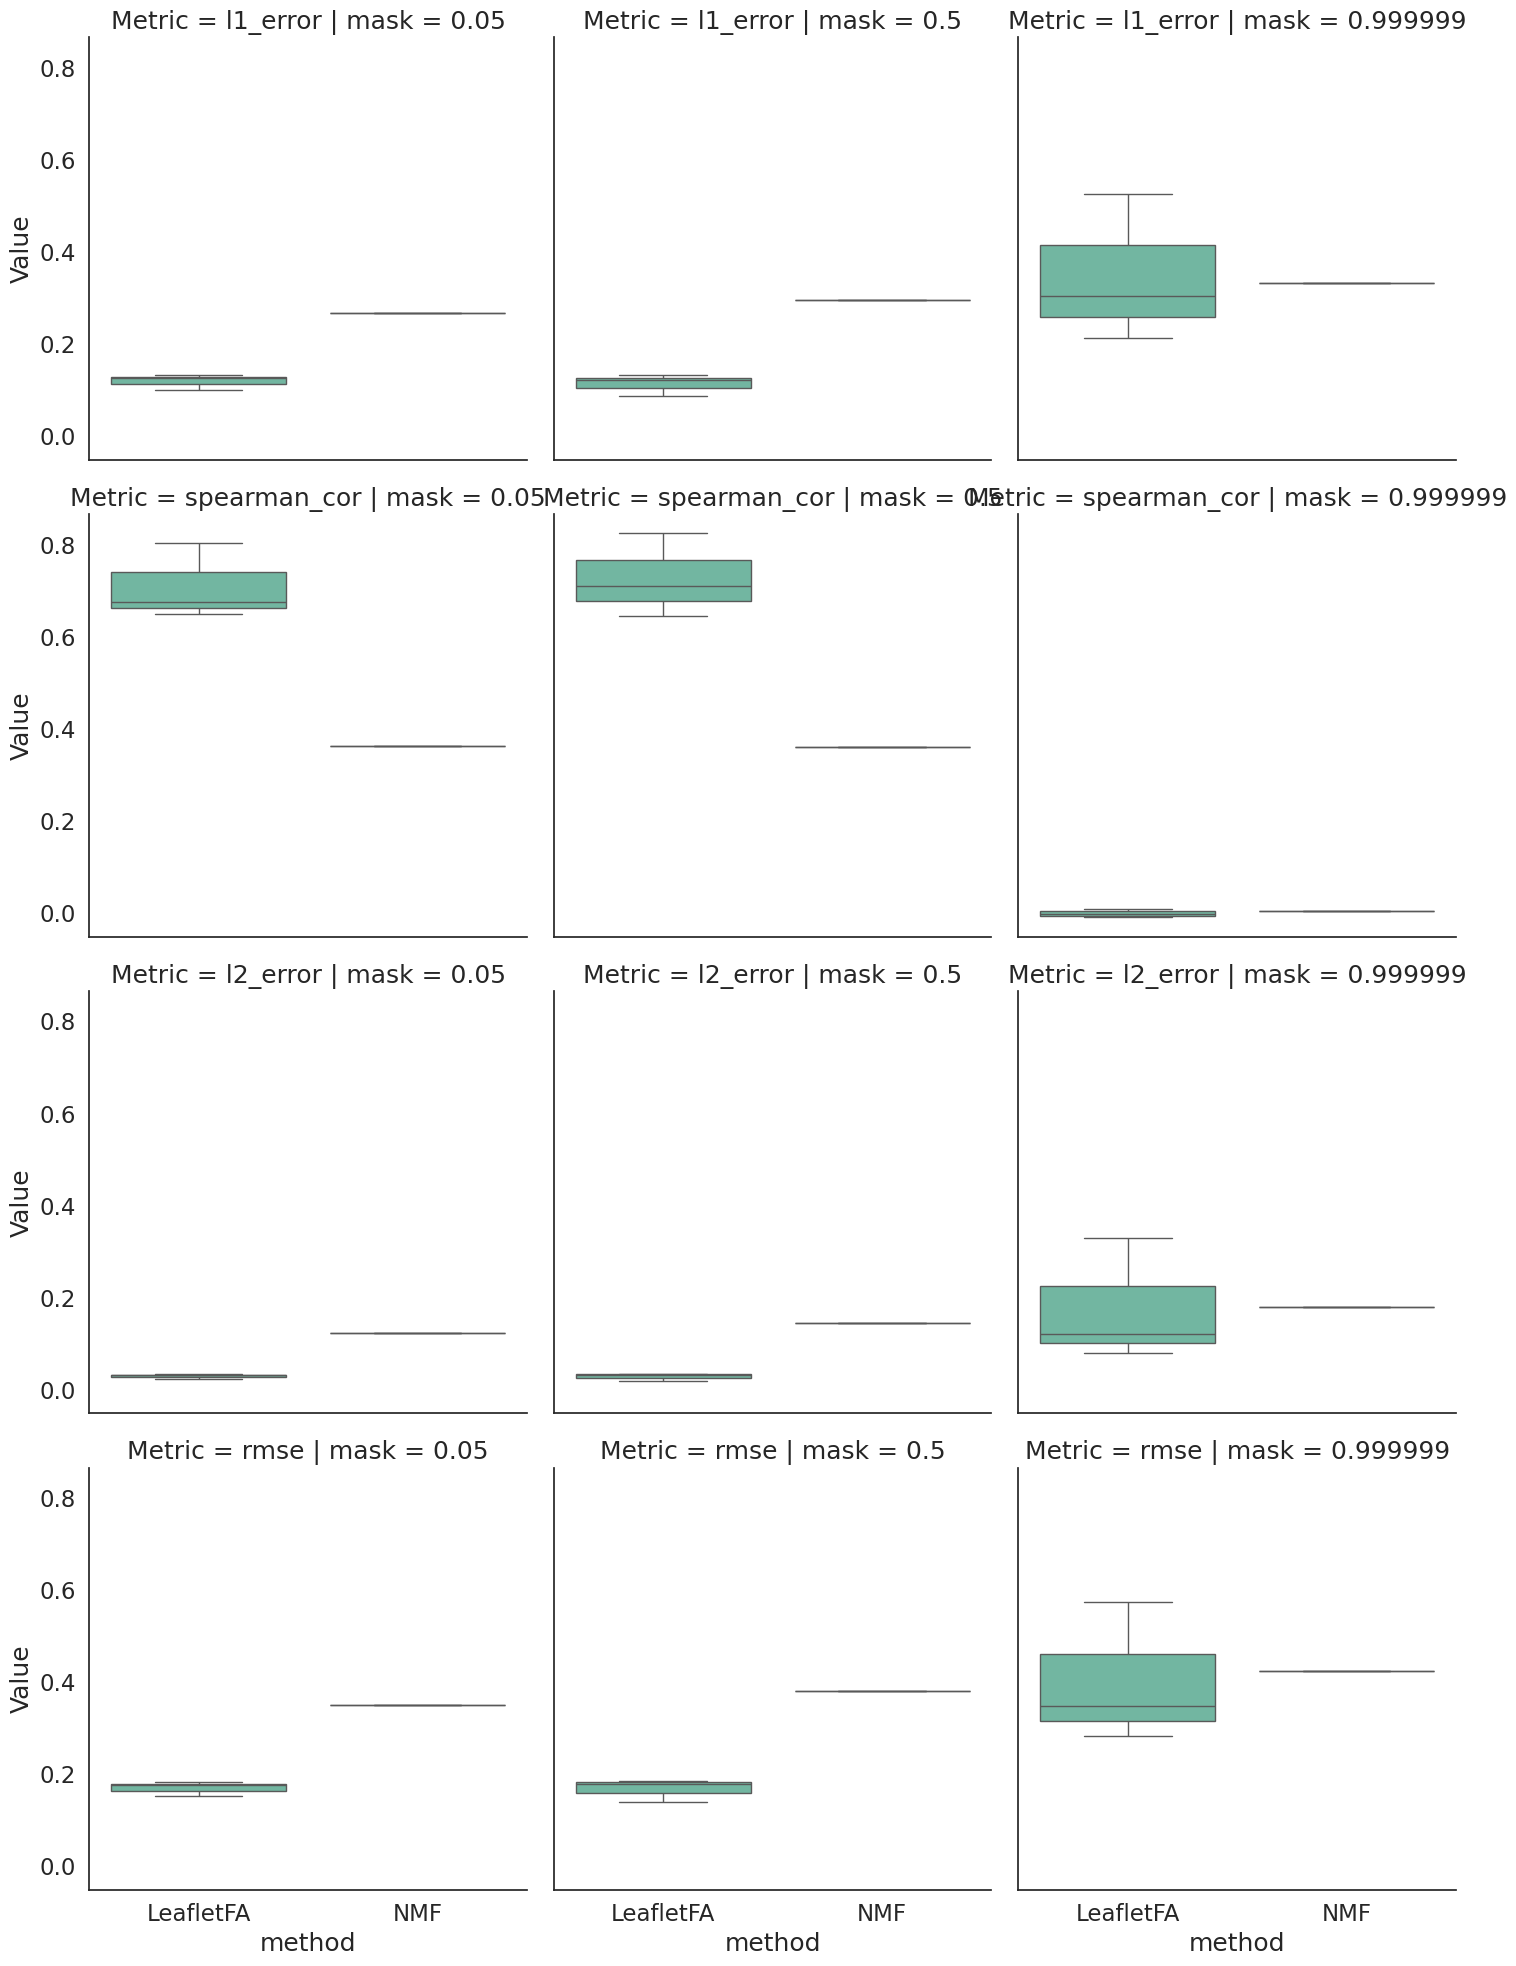

In [53]:
# Boxplot for each metric and method
# Plotting with 'mask' as an additional facet using sns.catplot
g = sns.catplot(
        data=combined_melted_df,
        x="method", y="Value", hue="method",
        col="mask", row="Metric", 
        kind="box", palette="Set2")

# Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()

In [ ]:
# Calculate mean and standard deviation for each method and metric
summary_stats = combined_melted_df.groupby(['method', 'Metric']).agg(['mean', 'std']).reset_index()

# Rename columns for easier reference
summary_stats.columns = ['method', 'Metric', 'mean', 'std']

# Set up the plot
plt.figure(figsize=(10, 6))

# Create a barplot with separate bars for each method
sns.barplot(data=summary_stats, x="Metric", y="mean", hue="method", ci=None, capsize=0.1)

# Add error bars manually for each method and metric
methods = summary_stats['method'].unique()
metrics = summary_stats['Metric'].unique()

# Loop over each method and metric and add error bars
for method in methods:
    for metric in metrics:
        # Filter the data for the current method and metric
        subset = summary_stats[(summary_stats['method'] == method) & (summary_stats['Metric'] == metric)]
        mean_value = subset['mean'].values[0]
        std_value = subset['std'].values[0]

        # Get the x-position of the current bar
        xpos = metrics.tolist().index(metric) + (methods.tolist().index(method) * 0.2) - 0.1

        # Add error bar for the current method and metric
        plt.errorbar(x=xpos, y=mean_value, yerr=std_value, fmt='none', c='black', capsize=5)

# Add labels and title
plt.title('Mean and Standard Deviation of Factor Model vs NMF Across Metrics')
plt.xlabel('Metric')
plt.ylabel('Mean Value')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
